# Customer Churn Prediction
- In this project our main goal is to provide telecom company a strategic insight,analysis of the data and predictive modelling to minize their retention and what are the services that is affecting the people to churn.
- We will also calculate the business impact assesment by getting the CLV(Customer lifetime value) to see eactly how much yearly revenue they loose when their customers churned, also how much each customer averagely spending on service during entire lifetime from start to end on the company.
- Each row represents customer, with features about their service used, and billing details. The target variable is Churn(Yes/No)"



In [85]:
# importing  all needed libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Filtering warnings to avoid furthur issues of plotting and model building
import warnings
warnings.filterwarnings('ignore', category= UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import joblib
import streamlit as st

In [86]:
# Loading Data
df = pd.read_csv("../data/churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [87]:
#Basic Dataset structure and info
print(f"Dataset shape: {df.shape[0]} rows * {df.shape[1]} columns")

print("\n Columns:")
print(df.columns.tolist())

print("\n Data info")
df.info


Dataset shape: 7043 rows * 21 columns

 Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

 Data info


<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

# Statistics~

- we begin it by checking summary of all numeric columns.
This helps us spot outliers,mean,median,max,min,standard deviation,understand Distribution and verify data. 

In [88]:
#Summary statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- here it didnt include totalcharges because it is stored as object

In [89]:
print(df['TotalCharges'].dtype)

object


In [90]:
# Fixing the Datatype of TotalCharges from 'Object'->'Float'
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(f"TotalCharges type after fix: {df.dtypes['TotalCharges']}")

TotalCharges type after fix: float64


In [91]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


- we now check for missing values in overall data and also which is introduced during Data type conversion.

In [92]:
# Counting the number of null values in each column
missing = df.isnull().sum()
# Only showing the column which has nan value
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing Values in Columns: \n",missing)

Missing Values in Columns: 
 TotalCharges    11
dtype: int64


In [93]:
df.drop('customerID', axis = 1, inplace=True)

Dropping 'customerID' because it's just a unique label it doesnt have any predictive power, keeping it would only create problems in visualization and building model.

In [94]:
print('customerID' in df.columns)

False


In [95]:
# Inspecting those 11 Rows
df['TotalCharges'].isna().sum()
df.dropna(inplace=True)
print(f"\n No missing vlaues found: {df['TotalCharges'].isnull().sum()}")


 No missing vlaues found: 0


# -EDA (Exploratory Data Analysis)
- Numerical feature Distribution 
 - Visualizing the spread and skewness of the key numerical columns: 'tenure','MonthlyCharges', and 'TotalCharges'.This helps understand customer Behavior and patterns and potential outlier

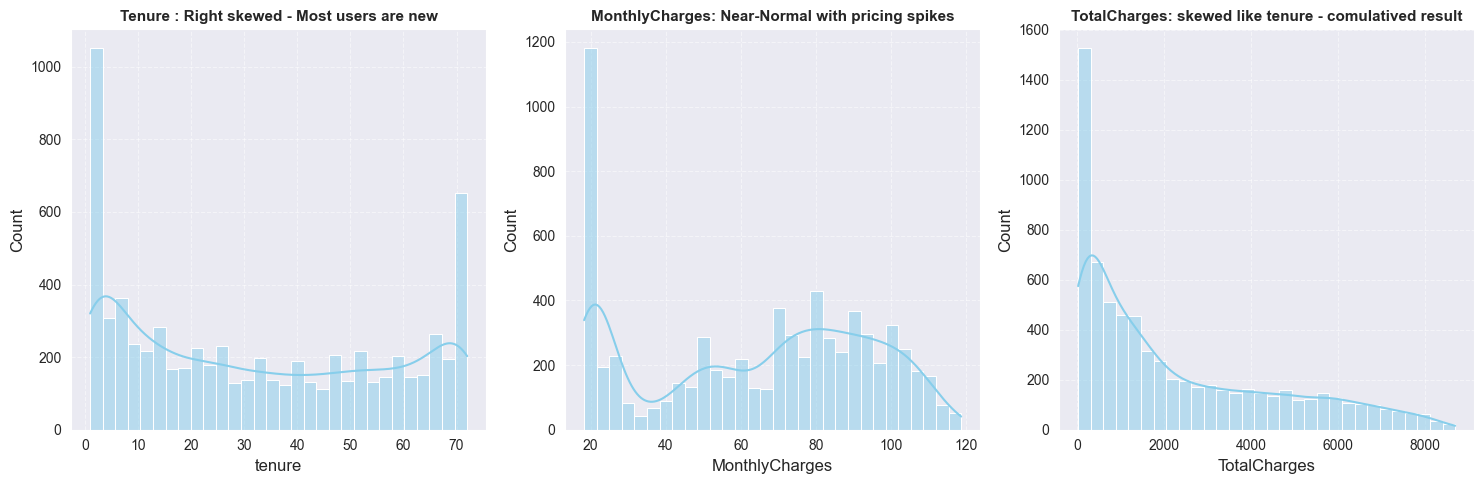

In [96]:
# Distribution plot for Numerical Features
features = ['tenure','MonthlyCharges','TotalCharges']
titles = ["Tenure : Right skewed - Most users are new",
          "MonthlyCharges: Near-Normal with pricing spikes",
          "TotalCharges: skewed like tenure - comulatived result"]

plt.figure(figsize=(15,5))

for i,col in enumerate(features):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col],kde=True,color='skyblue',bins=30)
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.xlabel(col)
    plt.grid(True, linestyle='--',alpha=0.5)
plt.tight_layout()
plt.savefig("../Visuals/Distribution.histplot.png")
plt.show()

Customer with low 'TotalCharges' and short 'Tenure' may represent recent joiner who are more likely to churn early. we likely need a better 'Onboarding' strategy to keep people from leaving in their first 6-8 months.if the cost of group($70+) is churning faster than $20 group.if so then price might be too high for the value provided.The business is heavily dependent on constantly coming new users only few customers stay long enough to become "high lifetime customer".

In [97]:
# Numerical columns we want to check for outliers
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

<Figure size 640x480 with 0 Axes>

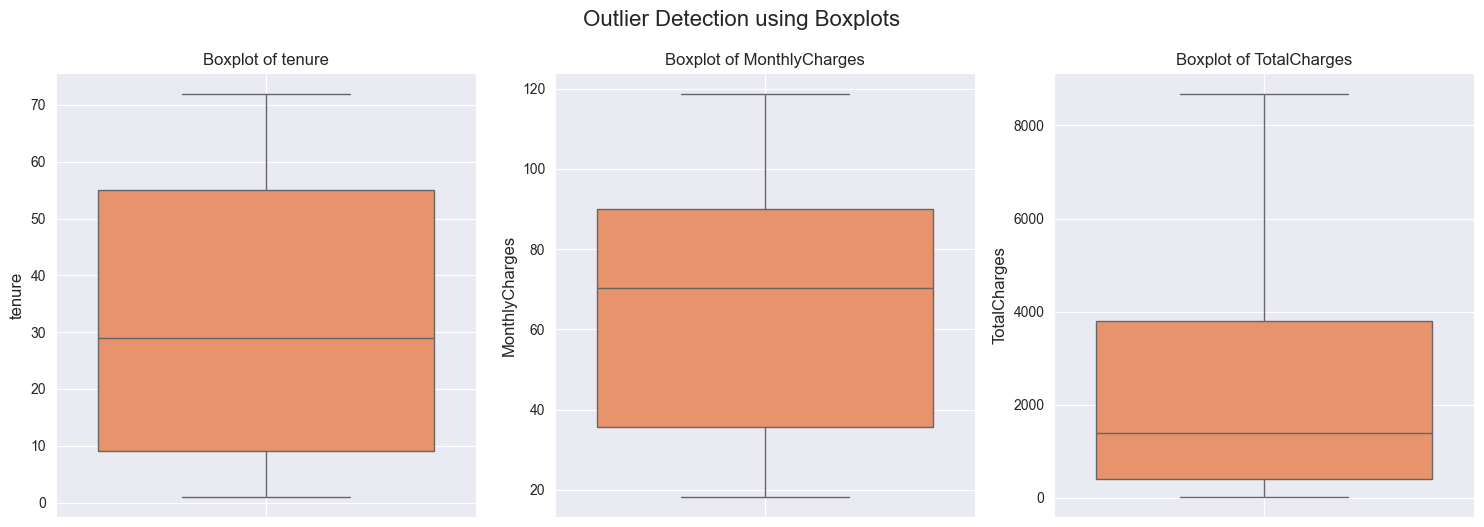

In [98]:
# Visualizing outliers using Boxplots
plt.clf()
plt.figure(figsize=(15,5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(data=df, y=col, palette= 'OrRd')
    plt.title(f"Boxplot of {col}",fontsize=12)
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Outlier Detection using Boxplots",fontsize=16, y=1.05)
plt.savefig("../Visuals/Outliers.Boxplot.png")
plt.show()

-"TotalCharges", "MontlyCharges"shows minor change on Outlier on the upper end.
-"tenure" seems fairly well-distributed with no extreme Outliers.
-These Outliers are not errors - Likely high-paying,Long-Term customers.
  

- Mathematical representation to check exactly if their exist Outlier in TotalCharges 

In [99]:
# IQR Method to detect Exact Outlier (For TotalCharges):-
Q1=df['TotalCharges'].quantile(0.25)
Q3=df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['TotalCharges'] < Q1 - 1.5 * IQR)  | (df['TotalCharges'] > Q3 + 1.5 * IQR)]
print(f"Outlier Rows in TotalCharges: {outliers.shape[0]}")


Outlier Rows in TotalCharges: 0


Using the IQR method we found 0 Outliers in the "TotalCharges"column.
This confirms that the column is clean and Normally spread.

# -Categorical Feature Distribution

In [100]:
# Extract categorical features (Excluding Target)
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_features.remove('Churn')
print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


We Removed 'Churn' as it was Targeted column not Feature.

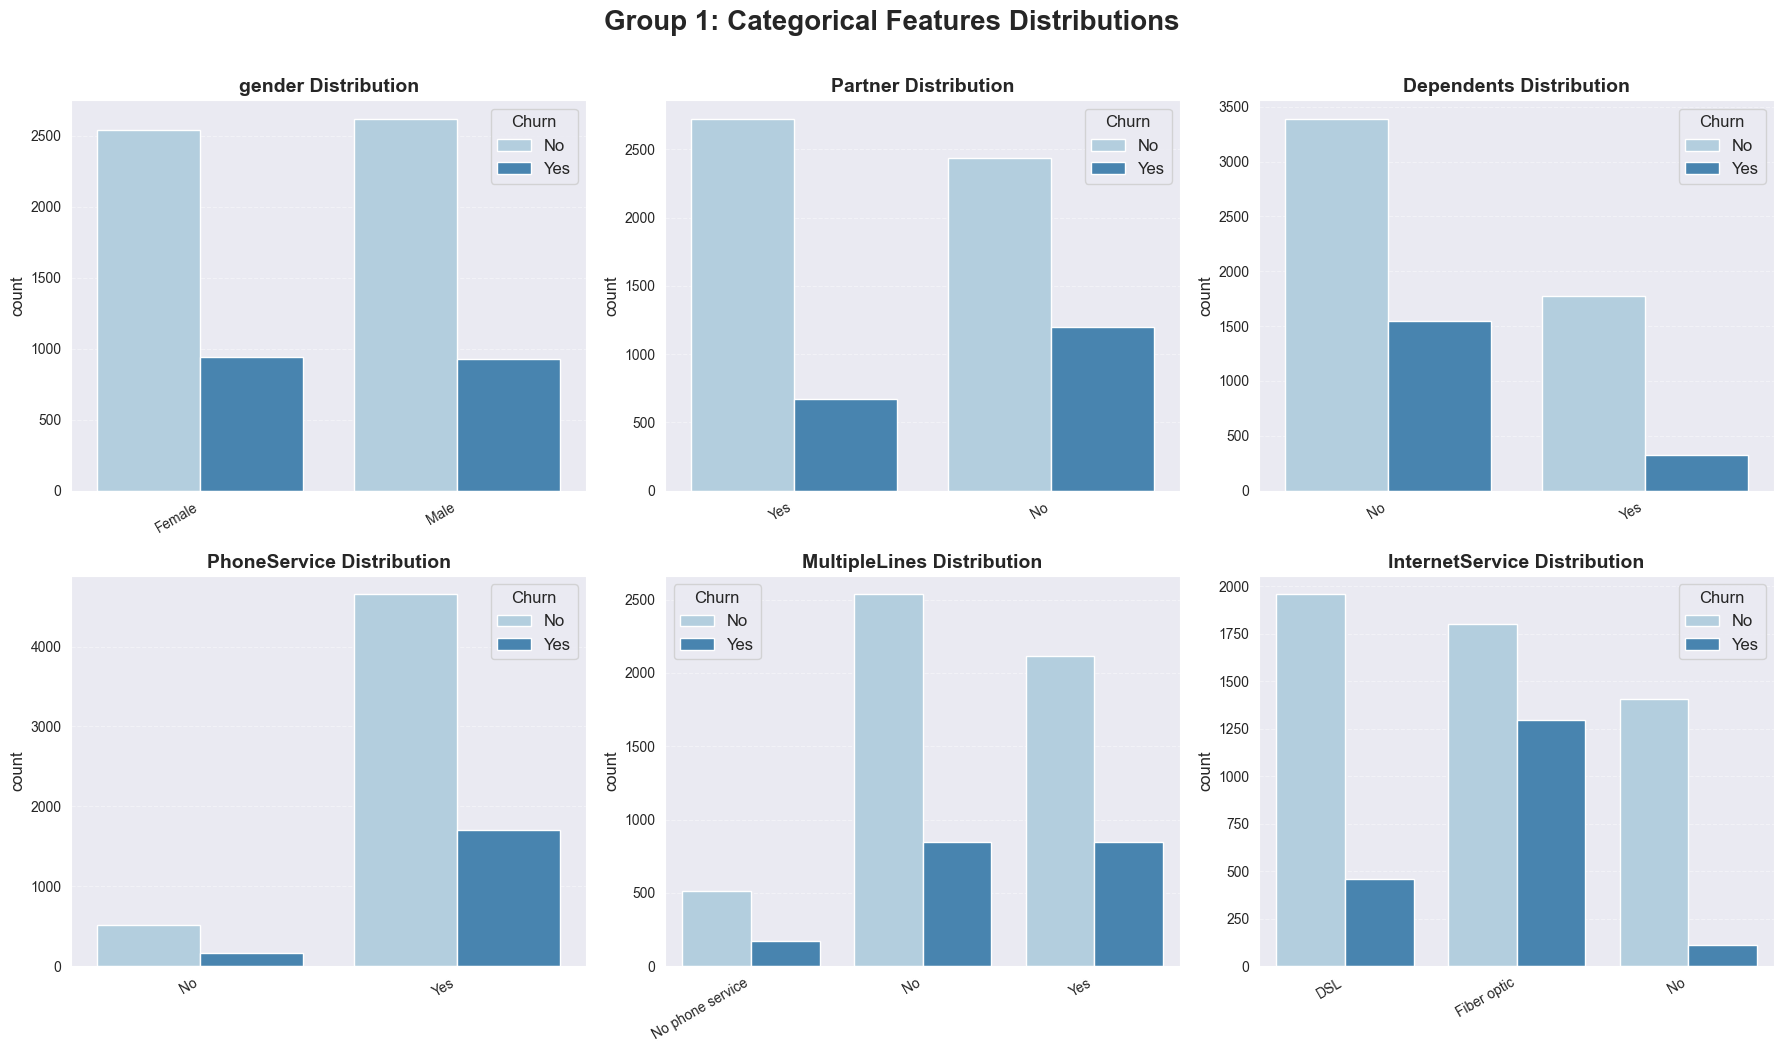

In [101]:
# Barplot for First 6 Categorical Features (Group 1)
plt.figure(figsize=(18, 10))

for i, col in enumerate(categorical_features[:6], 1):
    plt.subplot(2, 3, i)
    sns.countplot(data = df, hue = 'Churn', x = col, palette='Blues')
    plt.title(f"{col} Distribution", fontsize = 14, weight ='bold')
    plt.xlabel('')
    plt.xticks(rotation = 30, ha = 'right')
    plt.grid(axis ='y', linestyle = '--', alpha = 0.4)
plt.tight_layout()
plt.suptitle("Group 1: Categorical Features Distributions", fontsize= 20, y=1.05, fontweight = 'bold')
plt.savefig("../Visuals/Feature Distribution.countplot.png")
plt.show()

Group 1 : 
- 'gender Distribution': Almost equal split between male and female the churn rate is same regardless of gender.
- 'partner Distribution': having a partner makes a customer more stable.Singles are 'high-risk'for leaving 
- 'Dependents Distribution': Customers with families almost never leave.This is likely because "family plans" are complicated to cancel.
- 'PhoneService Distribution': The vast majority of customer utlizes PhoneService. However the churn ratio remains consistent across both groups means that phone line is not a factor for customer retention.
- 'MultipleLines Distribution': Having multiple lines doesnt really protect the customer from churning wheather they have multiple lines or not they leave at the same rate means its not a major factor in churn.
- 'InternetService': FibreOptic customers are the highest risk. Even though Fibre is the better technology, these customer are leaving at much higher rate than DSL users. Fibre is more expensive .if the service isn't perfect, customer feels they aren't getting their money's worth and quit. 

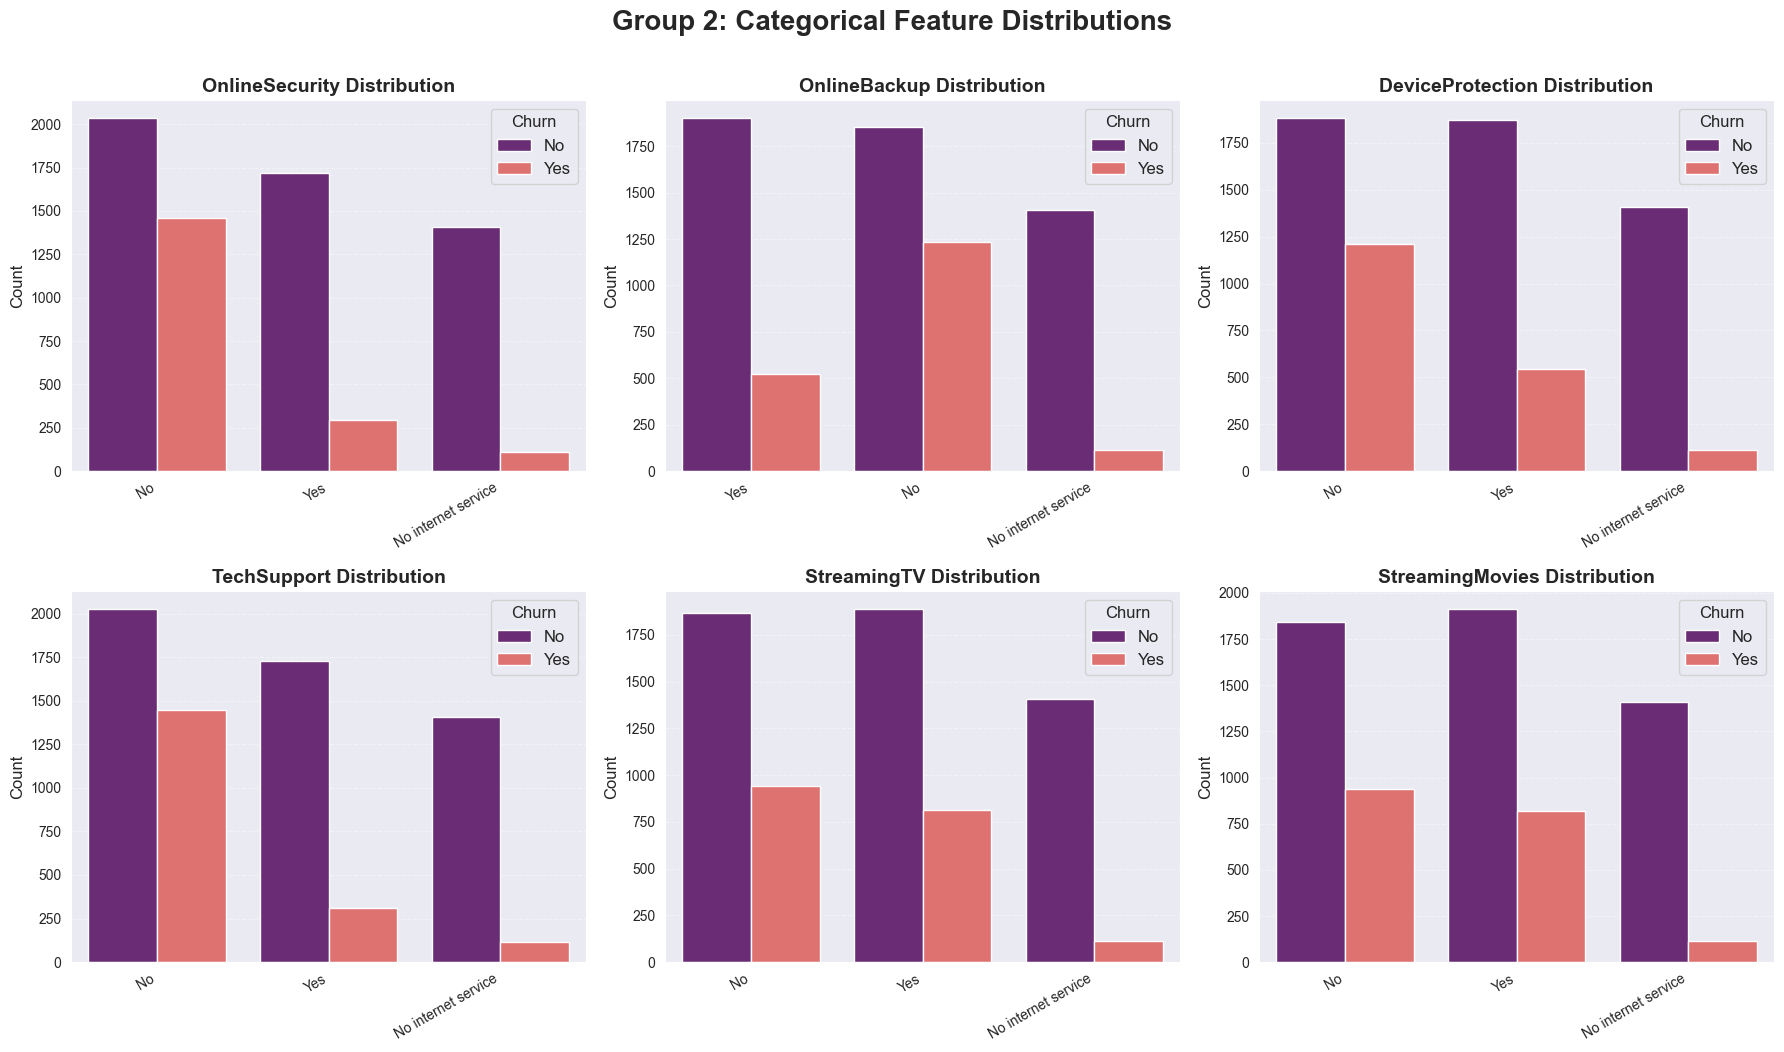

In [102]:
# Barplot for Next 6 Categorical Features (Group 2)

plt.figure(figsize=(18, 10))

for i , col in  enumerate(categorical_features[6:12], 1):
    plt.subplot(2, 3, i)
    sns.countplot(data = df,hue='Churn', x = col, palette='magma')
    plt.title(f"{col} Distribution", fontsize = 14, weight ='bold')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation = 30, ha = 'right')
    plt.grid(axis ='y', linestyle = '--', alpha = 0.4)
plt.tight_layout()
plt.suptitle("Group 2: Categorical Feature Distributions", fontsize= 20, y = 1.05, fontweight = 'bold')
plt.savefig("../Visuals/Features Distribution[2].countplot.png")
plt.show()

Group 2: "Protective-Service": I Observed that OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport all share an almost identical distribution.
- High Risk: Customers who do not have these services has significantly higher churn.
- High Loyalty: Customers who do have these services are much more 'sticky' and rarely leave.
- If we can move a customer from "No" to "Yes" in any of these categories, their probability of staying increases drastically.
- StreaminTV and StreamingMovies is good to add but, if a customer wants to leave for a better price elsewhere, they dont feel 'stuck' just because they have movies. They can get Netflix or Disney+ etc anywhere.

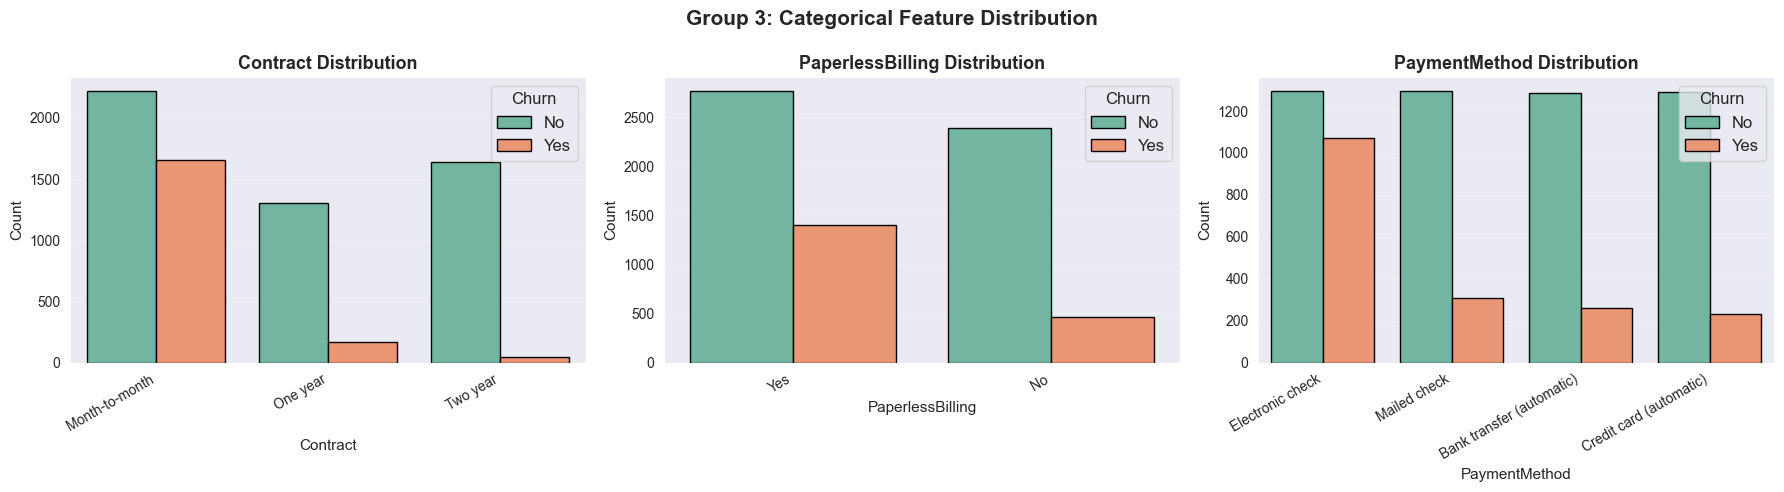

In [103]:
# Barplot For next Columns (Group 3)

group_3 = ['Contract', 'PaperlessBilling', 'PaymentMethod']

plt.figure(figsize=(18, 5))
for i, col in enumerate(group_3,1):
    plt.subplot(1, 3, i)
    sns.countplot(data = df,hue='Churn', x = col, palette= 'Set2', edgecolor = 'black')
    plt.title(f"{col} Distribution", fontsize = 13, weight = 'bold')
    plt.xlabel(col, fontsize = 11)
    plt.ylabel("Count", fontsize = 11)
    plt.xticks(rotation = 30, ha = 'right')
    plt.grid(axis = 'y', alpha = 0.3)

plt.suptitle("Group 3: Categorical Feature Distribution", fontsize = 15, weight = 'bold')
plt.tight_layout()
plt.savefig("../Visuals/Features Distribution[3].countplot.png")
plt.show()

Group 3: 
- 'Contract': Almost all of churn is coming from the customer who aren't locked into a contract.Once a customer signs a One-year or Two-year cotract,they basically stop churning.Incentivize month-to-month users to switch them into long term plans to "lock them in".
- 'PaperlessBilling': Customer with paperlessBilling have higher churn rate.Because customers are more tech-savy and price cautious, they find it easier to browse and look for their best fitted online deals which result in loosing customer.
- 'PaymentMethod': Customer using Electronic Checks often have high churn, while those on Automatic( Credit Card or Bank Transfer) stay much longer.We should encourage customers to set up Automatic Payments. It increases loyalty.

# Feature Analysis (Target Variable)
Comparing Important categorical feature with churn column to see how churn varies.

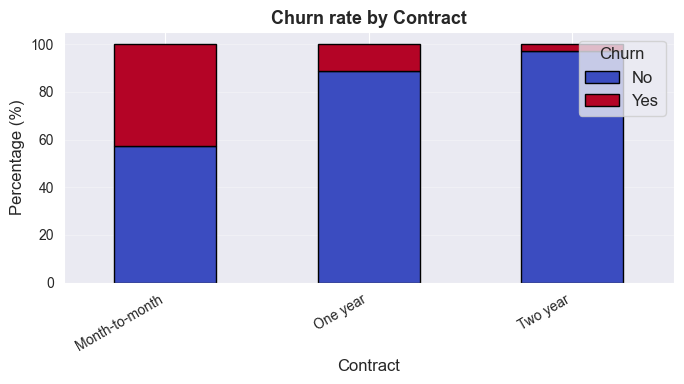

In [104]:
cols_to_plot = [
    'Contract',
    'PaymentMethod',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]
def plot_churn_percent(col):
    churn_pct = pd.crosstab(df[col], df['Churn'], normalize= 'index') * 100 
    churn_pct.plot(kind ='bar',stacked =True,figsize=(7, 4),colormap ='coolwarm',edgecolor = 'black')
    plt.title(f"Churn rate by {col}", fontsize= 13, weight = 'bold')
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation= 30,ha = 'right')
    plt.legend(title = 'Churn', loc = 'upper right')
    plt.grid(axis = 'y', alpha = 0.3)
    plt.tight_layout()
    plt.savefig("../Visuals/Feature Analysis[1].Barplot.png")
    plt.show()

plot_churn_percent("Contract")

- Month-to-Month customer shows higher churn rate. Where as Customer with One year or Two year Contracts are less likely to churn. Longer Contracts = less churn. The company should offer heavy discounts or free service upgrades like (month of free Netflix) to transition of Month-to-month users into One-Year or Two-Year Contracts. Even a small shift here will save thousand of customers.

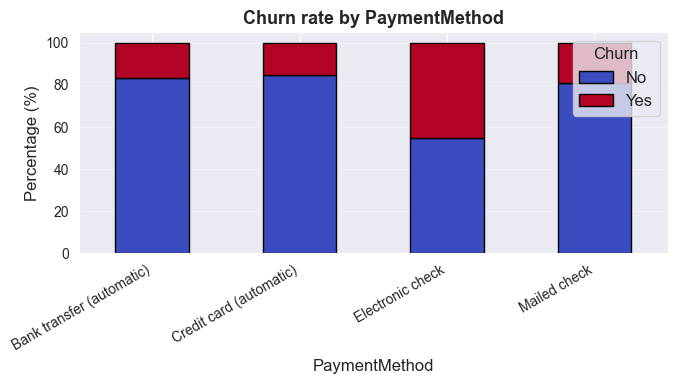

In [105]:
cols_to_plot = [
    'Contract',
    'PaymentMethod',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]
def plot_churn_percent(col):
    churn_pct = pd.crosstab(df[col], df['Churn'], normalize= 'index') * 100 
    churn_pct.plot(kind ='bar',stacked =True,figsize=(7, 4),colormap ='coolwarm',edgecolor = 'black')
    plt.title(f"Churn rate by {col}", fontsize= 13, weight = 'bold')
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation = 30, ha = 'right')
    plt.legend(title = 'Churn', loc = 'upper right')
    plt.grid(axis = 'y', alpha = 0.3)
    plt.tight_layout()
    plt.savefig("../Visuals/Feature Analysis[2].Barplot.png")

    plt.show()

plot_churn_percent("PaymentMethod")

- Customers using Electronic Checks churn more Frequently its a big red flag nearly half of people here leave. Those using Automatic(CreditCard,Banktransfer or Mailed check) have better performance.

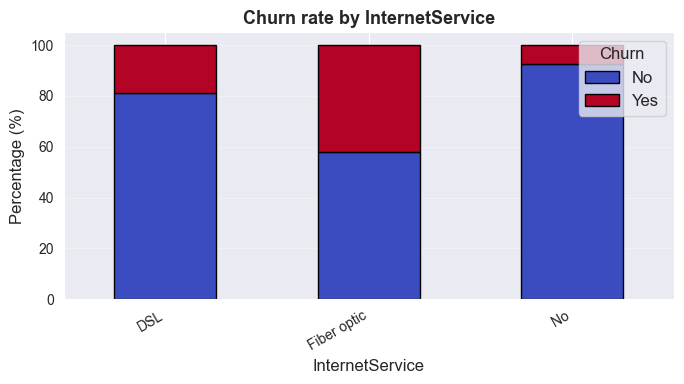

In [106]:
cols_to_plot = [
    'Contract',
    'PaymentMethod',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]
def plot_churn_percent(col):
    churn_pct = pd.crosstab(df[col], df['Churn'], normalize= 'index') * 100 
    churn_pct.plot(kind ='bar',stacked =True,figsize=(7, 4),colormap ='coolwarm',edgecolor = 'black')
    plt.title(f"Churn rate by {col}", fontsize= 13, weight = 'bold')
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation = 30, ha = 'right')
    plt.legend(title = 'Churn', loc = 'upper right')
    plt.grid(axis = 'y', alpha = 0.3)
    plt.tight_layout()
    plt.savefig("../Visuals/Feature Analysis[3].countplot.png")
    plt.show()

plot_churn_percent("InternetService")

- Customer with 'Fibre Optics' internet churn more.where as DSL user churn comparatively low. possibly due to pricing the money they are paying they are not getting enough service or issue with fibre.

# Targeted EDA

how numerical features like tenure, TotalCharges, MonthlyCharges Behaves with respect to churn.

In [107]:
# Tenure vs Churn plotly
fig = px.box(df, x='Churn',
             y = 'tenure',
             color = 'Churn',
             title='Tenure vs Churn',
             color_discrete_map = {'No':
                                   'green', 'Yes': 'crimson'})
fig.update_layout(template = 'plotly_dark')
fig.write_html("../Visuals/Tenure vs churn.Boxplot.html")
fig.show()

- people are more likely to leave the company early on. Most churning happens within the first 10 months of joining. The company shoud focus on New users, customers who stays longer has higher median tenure (usually around 38 months).

In [108]:
# MonthlyCharges vs Churn plotly

fig = px.box(df, x = 'Churn',
             y = 'MonthlyCharges',
             color = 'Churn',
             title = 'MonthlyCharges vs Churn',
             color_discrete_map = {'No':'magenta', 'Yes': 'goldenrod'})
fig.update_layout(template = 'plotly_dark')
fig.write_html("../Visuals/MonthlyCharges vs churn.Boxplot.html")
fig.show()

- Customer who churn (goldenrod) tends to have higher monthly charges on average around ($79.65). Non-churned customer (magenta) are mostly paying less monthly around($64.45), Customes who leave are generally paying $15 more per month on average than those who stay. which proves that high cost leads to high churn.

In [109]:
# TotalCharges vs Churn plotly

fig = px.violin(df, x = 'Churn',
                y = 'TotalCharges',
                color = 'Churn',
                box = True,
                points = 'all',
                title= 'TotalCharges Distribution by churn',
                color_discrete_map= {'No': 'blue', 'Yes': 'crimson'})
fig.update_layout(template = 'plotly_dark')
fig.write_html("../Visuals/TotalCharges vs churn.Violinplot.html")
fig.show()

- Customers who churned tends to have low distribution of TotalCharges indicates they left early, where as customer who did not churn shows higher and more spread out TotalCharges. Early stage customer are most likely to churn they leave before they can generate high lifetime value.

- The heatmap confirms that tenure is the most significant numerical factor in predicting retention. While the MonthlyCharges has a positive relationship with churn, the strong correlation (0.83)between TotalCharges and tenure suggests high feature redundancy between them.

# Feature Engineering & Preprocessing
- Binary Categorical Columns were label Encoded, multi-class Columns were One-hot encoded.

In [110]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the original DataFrame
df_encoded = df.copy()

# Label Encoding for Binary columns
binary_cols = ['gender', 'Partner', 
               'Dependents', 'PhoneService', 
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# One-Hot Encoding for Multi-Class columns
multi_class_cols = ['InternetService', 'Contract',
                    'PaymentMethod', 'MultipleLines',
                    'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies']

df_encoded = pd.get_dummies(df_encoded, columns=multi_class_cols)

df_encoded

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,True,False,False,True,False,False,True,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,True,False,False,True,False,False,True,False,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,True,False,False,True,False,False,True,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,True,True,False,False,True,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,True,False,False,True,False,False,True,False,False,True
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,True,True,False,False,False,False,True,False,False,True
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,False,True,False,False,True,False,False,True,False,False
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,False,True,False,False,True,False,False,True,False,False


In [111]:
pd.get_dummies(df, drop_first=True)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,True,False,True,False,False,True,False
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,True,True,False,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,True,False,False,True,True


- As we saw above on analysis that tenure was highly affecting the people to churn, but here after encoding we can see that 'MonthlyCharges' and 'TotalCharges' has higher values than tenure so our model will assume TotalCharges and MonthlyCharges are 100x more important than other like tenure just because they are bigger to fix this we will use scaling to make such columns mean 0 and variance 1

# Feature Scaling
- It will help our model to converge faster and to gain better performance on overall data provided rather than being magnitude bias .

In [112]:
from sklearn.preprocessing import StandardScaler
# Numeric columns to scale
num_cols = ['tenure','MonthlyCharges',
             'TotalCharges']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

df_encoded[num_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,-1.280248,-1.161694,-0.994194
1,0.064303,-0.260878,-0.173740
2,-1.239504,-0.363923,-0.959649
3,0.512486,-0.747850,-0.195248
4,-1.239504,0.196178,-0.940457


In [113]:
df_encoded[num_cols].describe

<bound method NDFrame.describe of         tenure  MonthlyCharges  TotalCharges
0    -1.280248       -1.161694     -0.994194
1     0.064303       -0.260878     -0.173740
2    -1.239504       -0.363923     -0.959649
3     0.512486       -0.747850     -0.195248
4    -1.239504        0.196178     -0.940457
...        ...             ...           ...
7038 -0.343137        0.664868     -0.129180
7039  1.612573        1.276493      2.241056
7040 -0.872808       -1.170004     -0.854514
7041 -1.158016        0.319168     -0.872095
7042  1.368109        1.357932      2.012344

[7032 rows x 3 columns]>

- Now our data is completely ready for training

## Train-Test Split
- We split the data into Training (80%) and Testing (20%) sets. This allow us to train the model on one portion of data and validate it's "real-world" performance on unseen data, to prevent overfitting. We will use stratify = y so that churn ratio remains consistent on both sets.

In [114]:
from sklearn.model_selection import train_test_split

# Features and Target
x = df_encoded.drop('Churn', axis = 1)
y = df_encoded['Churn']

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split( x, y, test_size= 0.2, random_state= 42, stratify= y)


# Confirm the split
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:",X_test.shape)
print("\nChurn Distribution in Training Set:")
print(Y_train.value_counts(normalize = True))
print("\nChurn Distribution in Testing Set")
print(Y_test.value_counts(normalize = True))

Training Set Shape: (5625, 40)
Testing Set Shape: (1407, 40)

Churn Distribution in Training Set:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Churn Distribution in Testing Set
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


The churn ratio is well-preserved in both train and test sets.

In [115]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)* 100


Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

- while splitting Train-Test some extra NAN introduced. We will fill these median before model Evauation and SMOTE(Synthetic Minority Oversampling Technique).

In [116]:
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(X_train['TotalCharges'].median())
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(X_test['TotalCharges'].median())

In [117]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_Two year                          0
PaymentMethod_Bank transfer (automatic)    0
PaymentMethod_Credit card (automatic)      0
PaymentMethod_Electronic check             0
PaymentMethod_Mailed check                 0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
OnlineSecu

## Class Balancing via SMOTE
- Our dataset is imbalanced (73% non-churn vs 26% churb) we first have to balance it before applying models otherwise it will affect our 'recall' and 'F1' which is essential For catching churn and our model will become bias towards majority class.

In [118]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

print("Before Smote:", Y_train.value_counts())
print("After Smote:", Y_train_resampled.value_counts())

Before Smote: Churn
0    4130
1    1495
Name: count, dtype: int64
After Smote: Churn
0    4130
1    4130
Name: count, dtype: int64


As Before our dataset was  highly imbalanced we applied smote and blanced it perfectly.

## Model Evaluation (Baseline) :-

### Logistic Regression

- Logistic Regression is simple yet powerful Classification Algorithm to start with, Ideal for Binary Classification. We'll Train it and Evaluate it's basic performance on test set.

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize the model
log_model = LogisticRegression(max_iter= 5000, random_state= 42)

# Fit the model
log_model.fit(X_train_resampled, Y_train_resampled)

# Predict on Test Set
y_pred_lr = log_model.predict(X_test)

# Evaluate the model
acc_lr = accuracy_score(Y_test, y_pred_lr)
prec_lr = precision_score(Y_test, y_pred_lr)
rec_lr = recall_score(Y_test, y_pred_lr)
f1_lr = f1_score(Y_test, y_pred_lr)

# Results
print("Logistic Regression performance:")
print(f"✅Accuracy : , {acc_lr: .4f}")
print(f"🎯Precision : {prec_lr: .4f}")
print(f"⏪Recall : {rec_lr: .4f}")
print(f"⭐F1-Score : {f1_lr: .4f}")

# Confusion Matrix
cm_lr = confusion_matrix(Y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)

Logistic Regression performance:
✅Accuracy : ,  0.7591
🎯Precision :  0.5362
⏪Recall :  0.6925
⭐F1-Score :  0.6044
Confusion Matrix:
 [[809 224]
 [115 259]]


- Overall Accuracy (~76%): The model correctly predicts customer behaviour with 3-4 cases.
- recall: Out of all the customers who actually churned, the model succesfully caught 259 of them (True positives).Good for the baseline.
- The Cost of False Alarms: By looking at the Confusion Matrix, there are 224 "False Positives"(the model said they'd leave, but they stayed). Due to this the customers might get unnecessary discounts or retention calls. which cost the company bit of money.
- The "Missed" Customers: There are 115 "False Negative"(the model said they'd stay, but they left). These are the most expensive mistakes because these customers leave forever.

### Random Forest Classifier 
- Churn data had complex interaction (e.g. tenure, contract type, payment method) that aren’t captured by linear models like Logistic Regression.
- Random Forest effectively captures this complex patterns, making it a strong model.

In [120]:
from sklearn.ensemble import RandomForestClassifier

# Initializing Random Forest
rf_model = RandomForestClassifier(random_state=42,class_weight='balanced')

# Fit Random Forest on Training data 
rf_model.fit(X_train_resampled, Y_train_resampled)

# Predict on Test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate Random forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_accuracy = accuracy_score(Y_test, rf_y_pred)
rf_precision = precision_score(Y_test, rf_y_pred)
rf_recall = recall_score(Y_test, rf_y_pred)
rf_f1 = f1_score(Y_test, rf_y_pred)

print(f"🌴Random Forest Classifier Performance:")
print(f"✅Accuracy : {rf_accuracy: .4f}")
print(f"🎯Precision : {rf_precision: .4f}")
print(f"⏪Recall : {rf_recall: .4f}")
print(f"⭐F1-Score : {rf_f1: .4f}")

# Confusion Matrix
cm = confusion_matrix(Y_test, rf_y_pred)
print("Confusion Matrix:\n", cm)

🌴Random Forest Classifier Performance:
✅Accuracy :  0.7697
🎯Precision :  0.5604
⏪Recall :  0.6203
⭐F1-Score :  0.5888
Confusion Matrix:
 [[851 182]
 [142 232]]


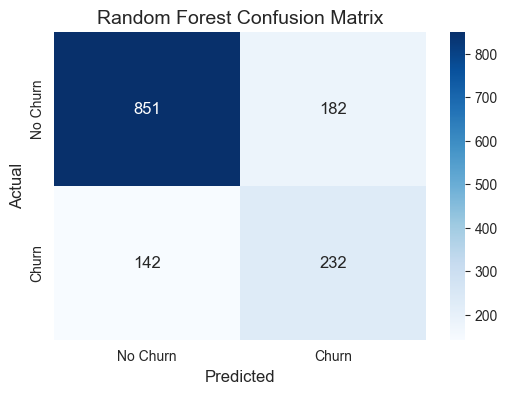

In [121]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(Y_test, rf_y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt = 'd', cmap='Blues', xticklabels= ['No Churn', 'Churn'], yticklabels= ['No Churn', 'Churn'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Strength: Very good at catching non-churners (881).
Weakness: Misses many churners (152)
Recall(Churn Detection): `50%

## Decision Tree


It is the intuitive model that split data based on feature values to make decisions


In [122]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the model
dtree = DecisionTreeClassifier(random_state=42)

# Train the model
dtree.fit(X_train_resampled, Y_train_resampled)

# Make Prediction
y_pred_dt = dtree.predict(X_test)

# Evaluating Performance
accuracy_dt = accuracy_score(Y_test, y_pred_dt)
precision_dt = precision_score(Y_test, y_pred_dt)
recall_dt = recall_score(Y_test, y_pred_dt)
f1_dt = f1_score(Y_test, y_pred_dt)

# Results
print(f"Decision Tree Results:")
print(f"✅Accuracy: {accuracy_dt: .4f}")
print(f"🎯Precision: {precision_dt: .4f}")
print(f"⏪Recall: {recall_dt: .4f}")
print(f"⭐F1-Score: {f1_dt: .4f}")

cm = confusion_matrix(Y_test, y_pred_dt)
print("Confusion Matrix:\n", cm)

Decision Tree Results:
✅Accuracy:  0.7214
🎯Precision:  0.4792
⏪Recall:  0.5535
⭐F1-Score:  0.5136
Confusion Matrix:
 [[808 225]
 [167 207]]


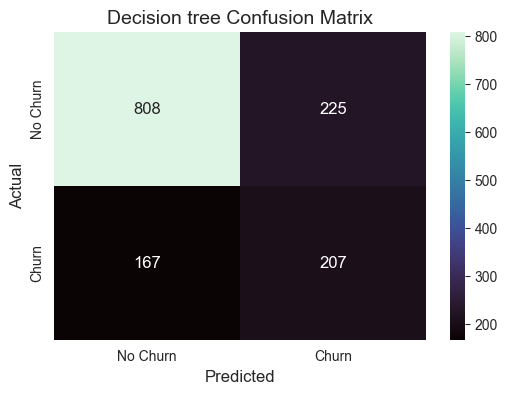

In [123]:
cm_dt= confusion_matrix(Y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt = 'd', cmap='mako', xticklabels= ['No Churn', 'Churn'], yticklabels= ['No Churn', 'Churn'])
plt.title("Decision tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Strength: More Churners Detected. Weakness: Less accurate for Loyal customers.

# K-Nearest Neighbour Classifier
KNN is a instance based learning based algorithm. It helps understand Local Patterns

In [124]:
# K-Nearest Neighbor Classifier
from sklearn.neighbors import KNeighborsClassifier

# Initializing  KNN with k = 5
knn_model = KNeighborsClassifier(n_neighbors = 5)

# Train the model
knn_model.fit(X_train_resampled, Y_train_resampled)

# Predict on test data
y_pred_knn = knn_model.predict(X_test)

# Evaluating performance
accuracy_knn = accuracy_score(Y_test, y_pred_knn)
precision_knn = precision_score(Y_test, y_pred_knn)
recall_knn = recall_score(Y_test, y_pred_knn)
f1_knn = f1_score(Y_test, y_pred_knn)

# Results
print(f"KNN Classifier Performance:")
print(f"✅Accuracy: {accuracy_knn: .4f}")
print(f"🎯Precision: {precision_knn: .4f}")
print(f"⏪Recall: {recall_knn: .4f}")
print(f"⭐F1-Score: {f1_knn: .4f}")

KNN Classifier Performance:
✅Accuracy:  0.7306
🎯Precision:  0.4953
⏪Recall:  0.7059
⭐F1-Score:  0.5821


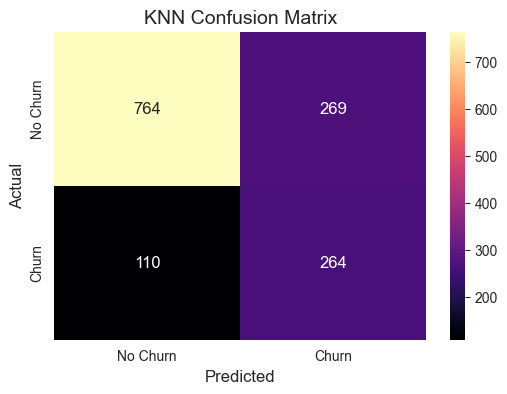

In [125]:
cm = confusion_matrix(Y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='magma', xticklabels= ['No Churn', 'Churn'], yticklabels= ['No Churn', 'Churn'])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Strength: Highest Churn Detection(268). Weakness: very high False alarms(256), Meaning Loyal customers wrongly flagged. Recall: Strong(But precision drops)

# XGBoost Classifier

Its a powerful ensemble technique based on gradient boosting that build trees sequentially to improve prediction accuracy.

In [126]:
# XGBoost Classifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, precision_score, recall_score, f1_score

# Initializing the model
xgb_model = XGBClassifier(use_label_encoder =False, eval_metric = 'logloss', random_state=42)

# Train the model
xgb_model.fit(X_train_resampled, Y_train_resampled)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluating Performance
acc_xgb = accuracy_score(Y_test, y_pred_xgb)
prec_xgb = precision_score(Y_test, y_pred_xgb)
rec_xgb = recall_score(Y_test, y_pred_xgb)
f1_xgb = f1_score(Y_test, y_pred_xgb)

# Results
print(f"XGBoost Classifier Performance:")
print(f"✅Accuracy: {acc_xgb: .4f}")
print(f"🎯Precision: {prec_xgb: .4f}")
print(f"⏪Recall: {rec_xgb: .4f}")
print(f"⭐F1-Score: {f1_xgb: .4f}")

XGBoost Classifier Performance:
✅Accuracy:  0.7640
🎯Precision:  0.5493
⏪Recall:  0.6257
⭐F1-Score:  0.5850


In [127]:
# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

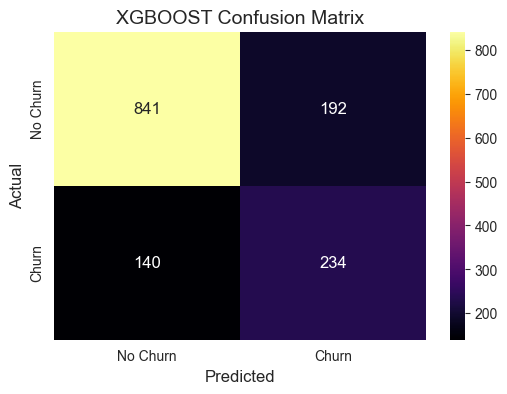

In [128]:
cm = confusion_matrix(Y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='inferno', xticklabels= ['No Churn', 'Churn'], yticklabels= ['No Churn', 'Churn'])
plt.title("XGBOOST Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../Visuals/XGBOOST Confusion Matrix Heatmap.png")
plt.show()

Strength: Balanced -good churn detection (164)without too many false alarms. Weakness: Slightly fewer (164)then knn and decision tree, but better overall.

In [129]:
# Model Comparison
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest','Decision Tree', 'KNN', 'XGBoost'],
    'Accuracy': [acc_lr, rf_accuracy, accuracy_dt, accuracy_knn,acc_xgb],
    'Precision': [prec_lr, rf_precision, precision_dt, precision_knn, prec_xgb],
    'Recall': [rec_lr, rf_recall, recall_dt, recall_knn, rec_xgb],
    'F1-Score': [f1_lr, rf_f1, f1_dt, f1_knn, f1_xgb] 
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.759062,0.536232,0.692513,0.604434
1,Random Forest,0.769723,0.560386,0.620321,0.588832
2,Decision Tree,0.721393,0.479167,0.553476,0.513648
3,KNN,0.730633,0.495310,0.705882,0.582139
4,XGBoost,0.764037,0.549296,0.625668,0.585000


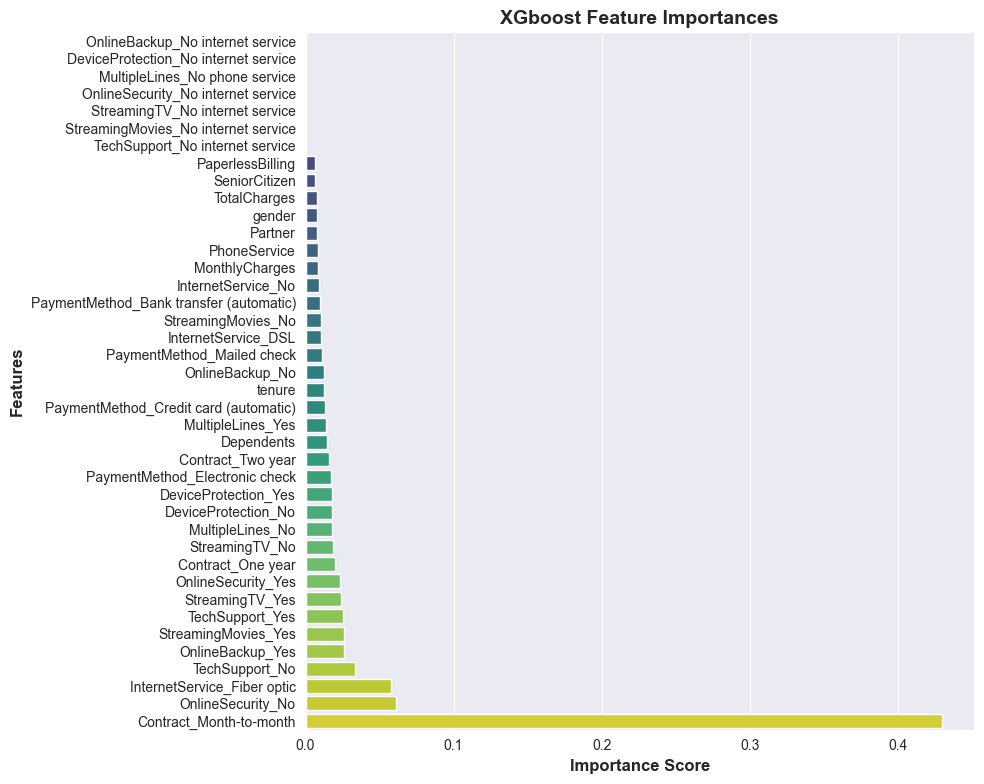

In [130]:
feature_imp_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10,8))
sns.barplot(x = 'Importance', y = 'Feature', data = feature_imp_df, palette='viridis')
sns.set_style("darkgrid")
plt.title("XGboost Feature Importances", fontsize = 14, weight = 'bold')
plt.xlabel("Importance Score", weight = 'bold')
plt.ylabel("Features", weight = 'bold')
plt.tight_layout()
plt.show()

Top Contributing Feature - "InternetService_Fibre optic" possibly paying more and facing issues lead to higher churn, "Contract-month-to-month" also  has high impact on churn prediction. Many Moderate Feature has also Influence Contributers.

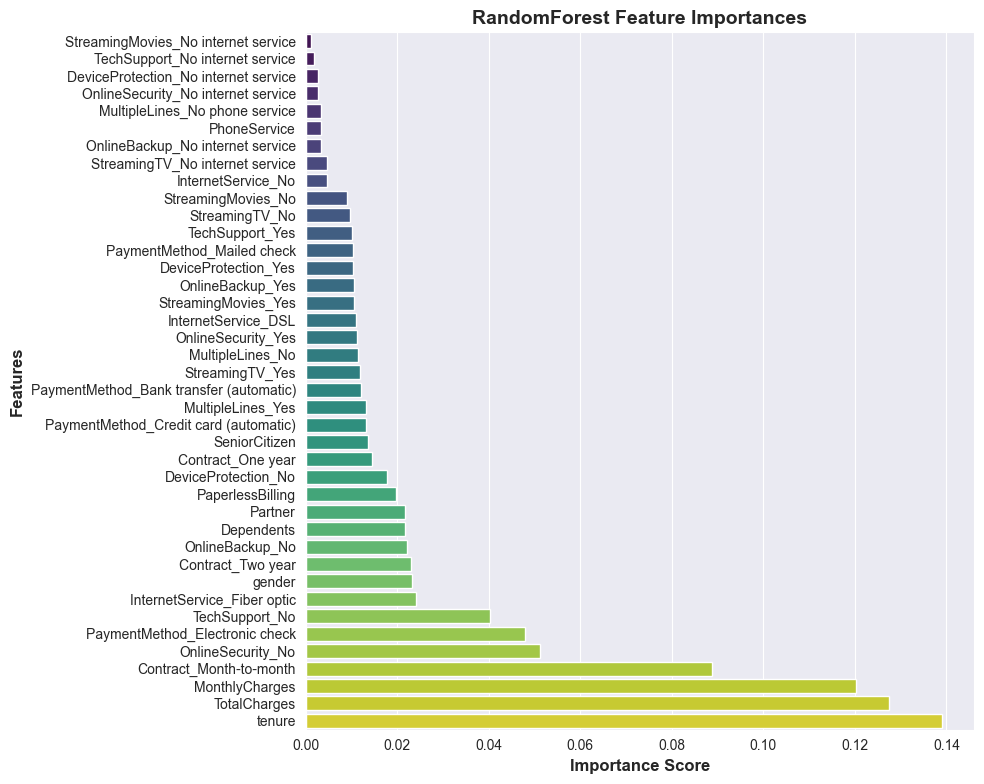

In [131]:
feature_imp_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10,8))
sns.barplot(x = 'Importance', y = 'Feature', data = feature_imp_df, palette='viridis')
sns.set_style("darkgrid")
plt.title("RandomForest Feature Importances", fontsize = 14, weight = 'bold')
plt.xlabel("Importance Score", weight = 'bold')
plt.ylabel("Features", weight = 'bold')
plt.tight_layout()
plt.savefig("../Visuals/Features Importance.Barplot.png")
plt.show()

In [132]:
# Model Comparison
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest','Decision Tree', 'KNN', 'XGBoost'],
    'Accuracy': [acc_lr, rf_accuracy, accuracy_dt, accuracy_knn,acc_xgb],
    'Precision': [prec_lr, rf_precision, precision_dt, precision_knn, prec_xgb],
    'Recall': [rec_lr, rf_recall, recall_dt, recall_knn, rec_xgb],
    'F1-Score': [f1_lr, rf_f1, f1_dt, f1_knn, f1_xgb] 
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.759062,0.536232,0.692513,0.604434
1,Random Forest,0.769723,0.560386,0.620321,0.588832
2,Decision Tree,0.721393,0.479167,0.553476,0.513648
3,KNN,0.730633,0.495310,0.705882,0.582139
4,XGBoost,0.764037,0.549296,0.625668,0.585000


# Model Comparison Table Baseline
This table compares  Accuracy, Precision, Recall, F1-Score accross All models before HyperParameter tuning.

In [133]:
results = { 'Model': ['Logistic Regression', 
           'Decision Tree', 'Random Forest',
           'KNN', 'XGBoost'],
           'Accuracy': [0.7786,0.7374,0.7828,0.7260,0.7793],
           'Precision': [ 0.5738,0.5047,0.5904,0.4885,0.5806],
           'Recall': [0.6444,0.5749,0.5936,0.6845,0.6070],
           'F1-Score': [0.6071,0.5375, 0.5920,0.5702,0.5935]}

# Creating DataFrame
comparison_df = pd.DataFrame(results)


# Displaying Table
print("Model Comparison Table (Baseline)")
display(comparison_df)


Model Comparison Table (Baseline)


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7786,0.5738,0.6444,0.6071
1,Decision Tree,0.7374,0.5047,0.5749,0.5375
2,Random Forest,0.7828,0.5904,0.5936,0.5920
3,KNN,0.7260,0.4885,0.6845,0.5702
4,XGBoost,0.7793,0.5806,0.6070,0.5935


From this it's clearly been seen that logistic regression perform well, so it has limited tuning scope. so we will take our rest top 2 model(Random Forest, XGBoost) and tune it.

# Hyperparameter Tuning
we'll perform hyperparameter tuning to optimize model performance in Random Forest & XGBoost.

In [134]:
# Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv = 5, scoring='f1', n_jobs = -1, verbose= 2)

# Fit GridSearchCV
grid_search.fit(X_train_resampled, Y_train_resampled)

# Best Parameters
print("Best Performance:", grid_search.best_params_)

# Best Estimator
best_model = grid_search.best_estimator_

# Evaluating on test set
y_pred_rf = best_model.predict(X_test)


acc_tuned = accuracy_score(Y_test, y_pred_rf)
prec_tuned = precision_score(Y_test, y_pred_rf)
rec_tuned = recall_score(Y_test, y_pred_rf)
f1_tuned = f1_score(Y_test, y_pred_rf)

# Results
print("\nTuned Random Forest Metrics:-\n")
print("Tuned  Random Forest Accuracy:", acc_tuned)
print("Tuned Random Forest Precision:", prec_tuned)
print("Tuned Random Forest Recall:", rec_tuned)
print("Tuned Random Forest F1-Score:", f1_tuned)
print("\n")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Performance: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest Metrics:-

Tuned  Random Forest Accuracy: 0.7668798862828714
Tuned Random Forest Precision: 0.5550239234449761
Tuned Random Forest Recall: 0.6203208556149733
Tuned Random Forest F1-Score: 0.5858585858585859




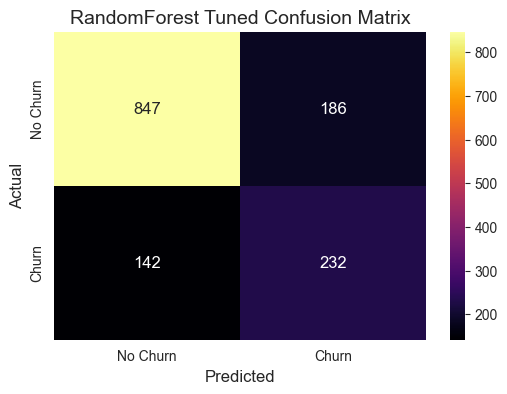

In [135]:
cm = confusion_matrix(Y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='inferno', xticklabels= ['No Churn', 'Churn'], yticklabels= ['No Churn', 'Churn'])
plt.title("RandomForest Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../Visuals/RandomForest Confusion Matrix Heatmap.png")
plt.show()

In [136]:
# XGBoost Classifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import  accuracy_score, precision_score, recall_score, f1_score

# Initialize model
xgb_model = XGBClassifier(use_label_encoder = False, eval_metric = 'logloss', random_state = 42)

# Define hyperParameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initializing GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv = 5, scoring='f1', n_jobs=-1, verbose=2)

# Fit GridSearchCV
grid_search.fit(X_train_resampled, Y_train_resampled)

# Best Parameters
print("Best Performance:", grid_search.best_params_)

# Evaluate Tune Model
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

acc = accuracy_score(Y_test, y_pred_tuned)
prec = precision_score(Y_test, y_pred_tuned)
rec = recall_score(Y_test, y_pred_tuned)
f1 = f1_score(Y_test, y_pred_tuned)

# Results
print("\nTuned XGBoost Metrics:-\n")
print("Tuned XGBoost Accuracy:", acc)
print("Tuned XGBoost Precision:", prec)
print("Tuned XGBoost Recall:", rec)
print("Tuned XGBoost F1-Score:", f1)
print("\n")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Performance: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

Tuned XGBoost Metrics:-

Tuned XGBoost Accuracy: 0.7647476901208244
Tuned XGBoost Precision: 0.5474613686534217
Tuned XGBoost Recall: 0.6631016042780749
Tuned XGBoost F1-Score: 0.599758162031439




In [137]:
#XGBoost Classifier Performance:
#✅Accuracy:  0.7640
#🎯Precision:  0.5493
#⏪Recall:  0.6257
#⭐F1-Score:  0.5850

In [138]:
y_pred_tuned = best_xgb.predict(X_test)

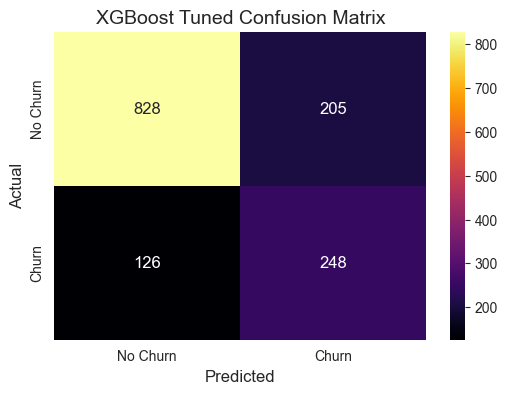

In [139]:
cm = confusion_matrix(Y_test,y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='inferno', xticklabels= ['No Churn', 'Churn'], yticklabels= ['No Churn', 'Churn'])
plt.title("XGBoost Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../Visuals/XGBOOST Confusion Matrix Heatmap.png")
plt.show()

# Evaluate on Test Set
Checking them on the unseen data for final performance.

In [140]:
# Random forest Classifier
from sklearn.metrics import classification_report


y_pred_rf_churn = best_model.predict_proba(X_test)
y_pred_proba = y_pred_rf_churn[:, 1]
y_pred_proba = np.asarray(y_pred_proba)


threshold = 0.37
boolean_predictions = (y_pred_proba >= threshold)
y_pred_churn_binary = boolean_predictions.astype(int)

print("Random Forest Tuned Evaluation(with threshold = 0.37):")
print(classification_report(Y_test,y_pred_churn_binary))

Random Forest Tuned Evaluation(with threshold = 0.37):
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.50      0.74      0.60       374

    accuracy                           0.74      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.78      0.74      0.75      1407



In [141]:
# print(f"type of y_pred: {type(y_pred)}")
# print(f"type of y_pred: {y_pred.shape}")

Limitations:
Although the tuned Random Forest model achieved an overall accuracy of 78%, it shows relatively low recall (50%) for class 1 due to class imbalance (class 0: 1035 samples, class 1: 374 samples). This means the model misses around half of class 1 cases, which could be critical if class 1 represents an important minority class. Future work can focus on addressing this limitation using class weighting, oversampling techniques, or threshold tuning to improve class 1 recall.

In [142]:
# XGBoost Classifier
from sklearn.metrics import classification_report

y_pred_tuned_xgb = best_xgb.predict_proba(X_test)
y_pred_tuned_proba = y_pred_tuned_xgb[:, 1]
y_pred_tuned_proba = np.asarray(y_pred_tuned_proba)



threshold = 0.37
boolean_predictions = (y_pred_tuned_proba >= threshold)
y_pred_tuned_churn_binary = boolean_predictions.astype(int)

print("XGBoost Tuned Evaluation(with threshold(0.37):")
print(classification_report(Y_test,y_pred_tuned_churn_binary))

XGBoost Tuned Evaluation(with threshold(0.37):
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.74      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.75      1407



on this above steps of evaluation on test set I specifically applied 'proba' and 'threshold=0.37, 38' because by not applying  it our model was primarily focusing only on majority class even though after smote our dataset gets balanced it was still focusing on 0(Majorityclass)and when i applied both of this parameter precision is dropping and its gaining recall an F1 then their might be two casses that it is taking true positives inside and giving result or it's catpturing with 51-52 % precision of the churners.

# Model Comparison Table (HyperParameter Tuned)

In [143]:
import plotly.graph_objects as go
import pandas as pd

comparison_df_tuned = pd.DataFrame({
    'Model': ['Random Forest Tuned Evaluation',
              'XGBoost Tuned Evaluation'],
              'threshold': [0.37, 0.37],
              'Accuracy(Test)': [0.75, 0.75],
              'F1(macro avg)': [0.70, 0.71],
              'F1(Weighted avg)': [0.75, 0.76],
              'Precision(Class 1)': [0.51, 0.52],
              'Recall(Class 1)': [0.70, 0.70],
              'F1(Class 1)': [0.59, 0.60]
})

print(comparison_df_tuned)

fig = go.Figure(data =[go.Table( header = dict(values = list(comparison_df_tuned.columns),
                                               fill_color = 'paleturquoise', align = 'left'),
                                               cells = dict( values = [comparison_df_tuned[col]
                                                            for col in comparison_df_tuned.columns],
                                                            fill_color = 'lavender', align = 'left'))])

fig.update_layout(title = "Model Comparison After Evaluation on Unseen Data:-")
fig.show()

                            Model  threshold  Accuracy(Test)  F1(macro avg)  \
0  Random Forest Tuned Evaluation       0.37            0.75           0.70   
1        XGBoost Tuned Evaluation       0.37            0.75           0.71   

   F1(Weighted avg)  Precision(Class 1)  Recall(Class 1)  F1(Class 1)  
0              0.75                0.51              0.7         0.59  
1              0.76                0.52              0.7         0.60  


need insights


# Business Impact Assesment
Calculating CLV (Customer Lifetime Value)- The average total revenue a customer generates during entire relationsship with bussiness, and Yearly Revenue Lost 

In [144]:
import pandas as pd

# Calculating CLV (Customer lifetime Value)
avg_monthly_revenue = df['MonthlyCharges'].mean()
avg_tenure_months = df['TotalCharges']/df['MonthlyCharges']
clv = avg = avg_monthly_revenue * avg_tenure_months.mean()

# Yearly Revenue Lost
churned_customers = df[df['Churn']== 'Yes'].shape[0]
yearly_revenue_lost = churned_customers * clv

print(f"Based on analysis of {len(df):,} customers.")
print(f"Average CLV: ${clv:.2f} per customer")

print(f"Yearly revenue lost to churn: ${yearly_revenue_lost:,.2f}")
print(f"Based on analysis of {len(df):,} customers.")

Based on analysis of 7,032 customers.
Average CLV: $2101.02 per customer
Yearly revenue lost to churn: $3,926,809.65
Based on analysis of 7,032 customers.


Every customer cost the company $2,101 in the lost revenue $3.9M per Year. certain 20 % of reduction in churn could save ~$785k yearly revenue.

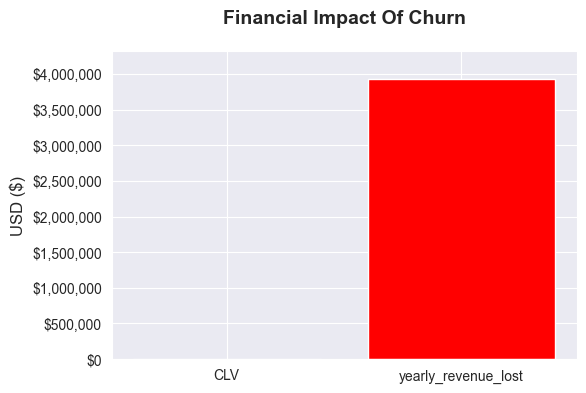

In [145]:
# By Visual Representation 

metrics = ['CLV', 'yearly_revenue_lost']
values = [2101.02, 3926809.65]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values, color= ['blue', 'red'])
plt.title('Financial Impact Of Churn', pad = 20 , weight = 'bold')
plt.ylabel('USD ($)')
plt.ylim(0 , max(values)*1.1)
plt.gca().set_yticklabels(['${:,.0f}'.format(x)
                           for x in plt.gca().get_yticks()])
plt.ylim()
plt.show()

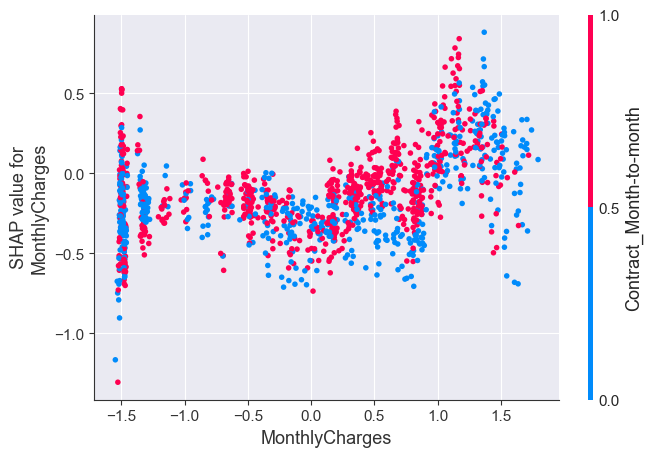

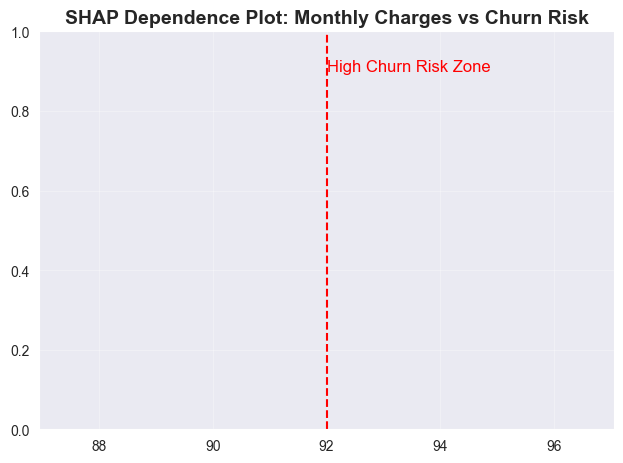

In [146]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)


if isinstance(shap_values, list) and len(shap_values)>1 :
    shap_dependence_values = shap_values[1]
else:
    shap_dependence_values = shap_values
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})
shap.dependence_plot('MonthlyCharges', shap_values, X_test)
plt.title("SHAP Dependence Plot: Monthly Charges vs Churn Risk", fontsize = 14, weight = 'bold')
plt.grid(alpha = 0.3)
plt.axvline(x =92, color = 'red', linestyle = '--')
plt.text(92, plt.ylim()[1]*0.9, 'High Churn Risk Zone', color = 'red')
plt.tight_layout()
plt.show()

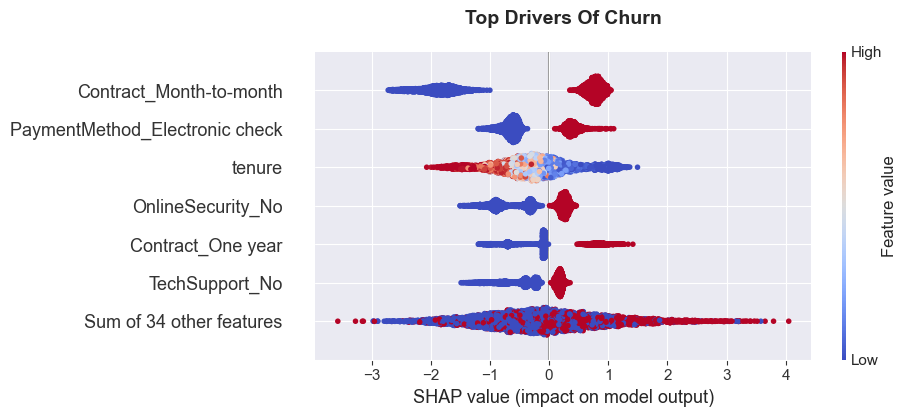

In [147]:
import shap
explainer = shap.Explainer(best_xgb)

shap_values = explainer(X_train)

if len(shap_values.shape) == 3:
    shap_values = shap_values[:,:,1]

shap.plots.beeswarm(shap_values, max_display = 7, color = plt.get_cmap("coolwarm"), show = False)

plt.title("Top Drivers Of Churn", weight = 'bold', pad = 20)
plt.gcf().set_size_inches(8, 4)
plt.show()

promote Yearly plans with discount to lock in customer and reduce churn, Implement early benifits schemes or loyalty programs within first few month to gain customer, improve fibre optic quality service issue

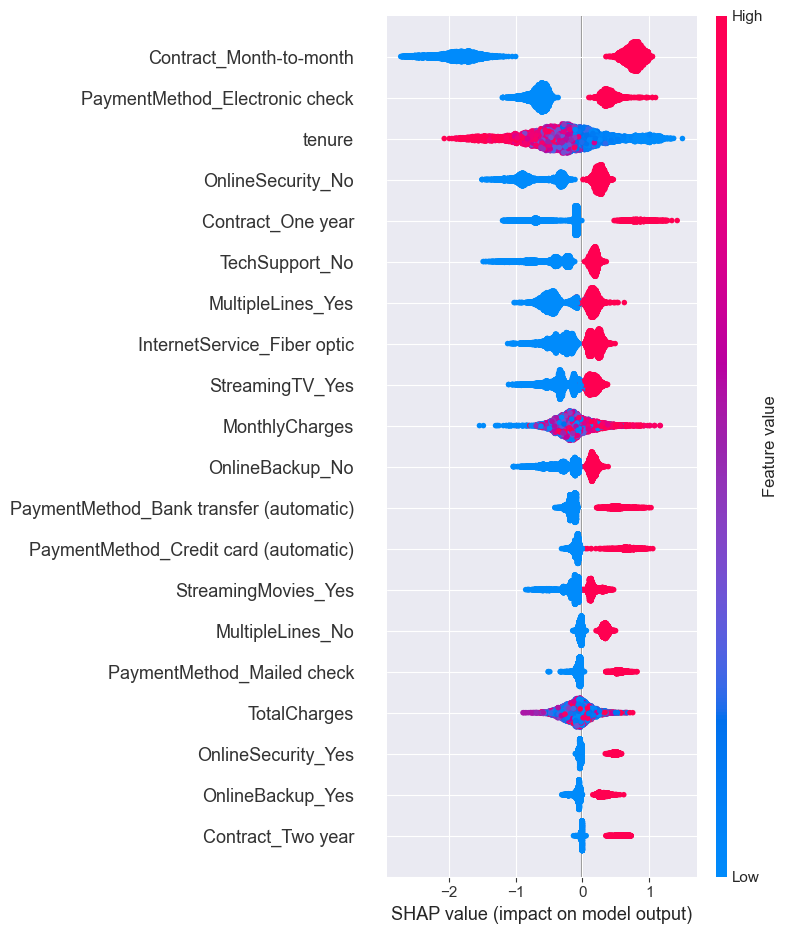

In [148]:
shap.summary_plot(shap_values)

In [149]:
print("model features:", best_xgb.feature_names_in_)

model features: ['gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure' 'PhoneService'
 'PaperlessBilling' 'MonthlyCharges' 'TotalCharges' 'InternetService_DSL'
 'InternetService_Fiber optic' 'InternetService_No'
 'Contract_Month-to-month' 'Contract_One year' 'Contract_Two year'
 'PaymentMethod_Bank transfer (automatic)'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check' 'MultipleLines_No'
 'MultipleLines_No phone service' 'MultipleLines_Yes' 'OnlineSecurity_No'
 'OnlineSecurity_No internet service' 'OnlineSecurity_Yes'
 'OnlineBackup_No' 'OnlineBackup_No internet service' 'OnlineBackup_Yes'
 'DeviceProtection_No' 'DeviceProtection_No internet service'
 'DeviceProtection_Yes' 'TechSupport_No' 'TechSupport_No internet service'
 'TechSupport_Yes' 'StreamingTV_No' 'StreamingTV_No internet service'
 'StreamingTV_Yes' 'StreamingMovies_No'
 'StreamingMovies_No internet service' 'StreamingMovies_Yes']


In [150]:
import joblib
joblib.dump(best_xgb, "aura.pk1")

['aura.pk1']

In [151]:
train_score = best_xgb.score(X_train, Y_train)
print(train_score)

0.8714666666666666


In [152]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_xgb, X_train, Y_train, cv = 5)

print("Train:", best_xgb.score(X_train, Y_train))

Train: 0.8714666666666666


In [153]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('smote', SMOTE()),
    ('model', best_xgb)
])

cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='roc_auc')

print("CV Mean:", cv_scores.mean())


CV Mean: 0.8309882821673537


In [154]:
train_score = pipeline.fit(X_train, Y_train).predict_proba(X_train)[:,1]
from sklearn.metrics import roc_auc_score
print(roc_auc_score(Y_train, train_score))

0.9384555459279114


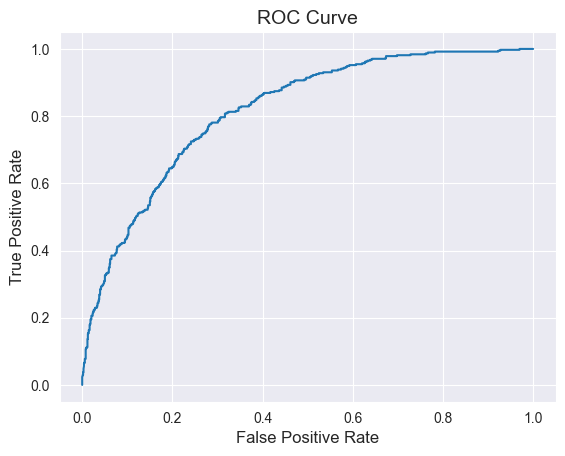

In [155]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

pipeline.fit(X_train, Y_train)
probs = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(Y_test, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [156]:
import pandas as pd

importance = pipeline.named_steps['model'].feature_importances_
pd.Series(importance, index=X_train.columns)\
  .sort_values(ascending=False)\
  .head(10)
print(importance)

[0.00786601 0.00621786 0.00723307 0.01537978 0.01259462 0.01068932
 0.00608813 0.00928159 0.00678258 0.00706598 0.05908252 0.
 0.49039838 0.01930737 0.01337848 0.00907102 0.00990656 0.01676746
 0.01059866 0.01817771 0.         0.01126063 0.06884544 0.
 0.02755903 0.01056852 0.         0.02001609 0.00990936 0.
 0.00906143 0.01703564 0.         0.02093962 0.0165443  0.
 0.013058   0.01554729 0.         0.0237676 ]


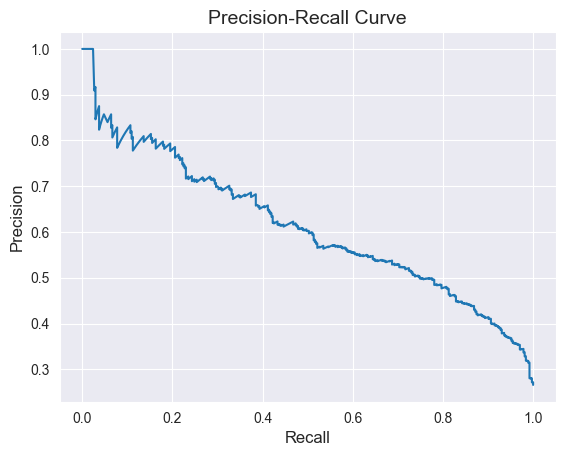

In [157]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(Y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


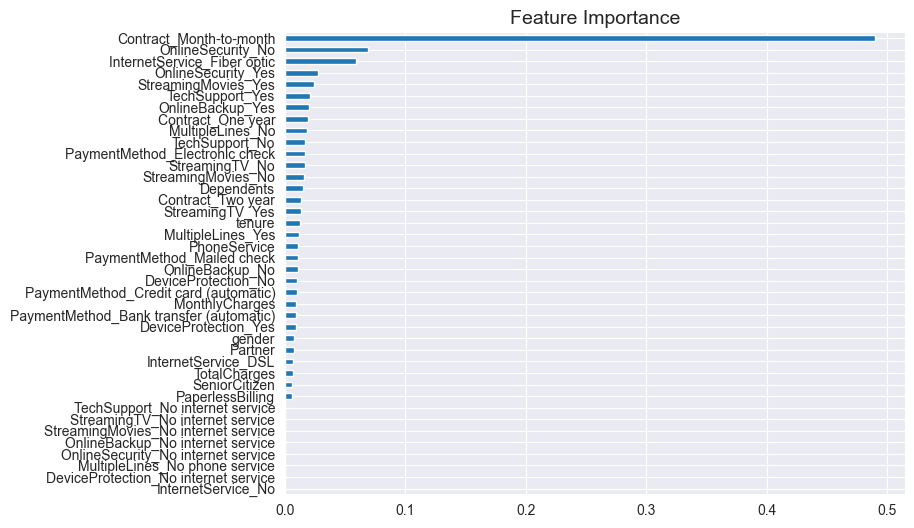

In [158]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pipeline.named_steps['model'].feature_importances_
pd.Series(importance, index=X_train.columns)\
  .sort_values(ascending=True)\
  .plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()


In [159]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline: SMOTE + Logistic
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("logistic", LogisticRegression(max_iter=5000, random_state=42))
])

# Hyperparameters to tune
param_grid = {
    "logistic__C": [0.01, 0.1, 1, 10],
    "logistic__class_weight": [None, "balanced"]
}

# Grid search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Fit only on original training data
grid.fit(X_train, Y_train)

# Best model
best_log_model = grid.best_estimator_

# Predict on test set
y_pred = best_log_model.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(Y_test, y_pred)
prec = precision_score(Y_test, y_pred)
rec = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print("Tuned Logistic Regression:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")

y_probs = best_log_model.predict_proba(X_test)[:,1]

threshold = 0.35
y_pred = (y_probs >= threshold).astype(int)

print(y_probs)

Tuned Logistic Regression:
Accuracy: 0.7477
Precision: 0.5185
Recall: 0.7112
F1: 0.5998
[0.02360701 0.78233348 0.01977058 ... 0.21801131 0.03812305 0.01271335]


In [160]:
# Logistic predicted probabilities
y_log_proba = best_log_model.predict_proba(X_test)[:, 1]
y_log_proba = np.asarray(y_log_proba)

# Try same threshold as XGBoost first
threshold = 0.37
y_log_binary = (y_log_proba >= threshold).astype(int)

print("Logistic Evaluation (threshold=0.37):")
print(classification_report(Y_test, y_log_binary))


Logistic Evaluation (threshold=0.37):
              precision    recall  f1-score   support

           0       0.91      0.66      0.76      1033
           1       0.47      0.83      0.60       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.80      0.70      0.72      1407



In [161]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('smote', SMOTE()),
    ('model', best_log_model)
])

cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='roc_auc')

print("CV Mean:", cv_scores.mean())


CV Mean: 0.8402111153400764


In [162]:
#Logistic Evaluation (threshold=0.37):
 #             precision    recall  f1-score   support
#
   #        0       0.90      0.73      0.81      1033
  #         1       0.51      0.78      0.62       374

    #accuracy                           0.74      1407
   #macro avg       0.70      0.75      0.71      1407
#weighted avg       0.80      0.74      0.75      1407

In [163]:
#XGBoost Tuned Evaluation(with threshold(0.37):
 #             precision    recall  f1-score   support

  #         0       0.89      0.75      0.81      1033
   #        1       0.52      0.73      0.61       374

    #accuracy                           0.75      1407
   #macro avg       0.70      0.74      0.71      1407
#weighted avg       0.79      0.75      0.76      1407

In [167]:
print(list(enumerate(X_train.columns)))

[(0, 'gender'), (1, 'SeniorCitizen'), (2, 'Partner'), (3, 'Dependents'), (4, 'tenure'), (5, 'PhoneService'), (6, 'PaperlessBilling'), (7, 'MonthlyCharges'), (8, 'TotalCharges'), (9, 'InternetService_DSL'), (10, 'InternetService_Fiber optic'), (11, 'InternetService_No'), (12, 'Contract_Month-to-month'), (13, 'Contract_One year'), (14, 'Contract_Two year'), (15, 'PaymentMethod_Bank transfer (automatic)'), (16, 'PaymentMethod_Credit card (automatic)'), (17, 'PaymentMethod_Electronic check'), (18, 'PaymentMethod_Mailed check'), (19, 'MultipleLines_No'), (20, 'MultipleLines_No phone service'), (21, 'MultipleLines_Yes'), (22, 'OnlineSecurity_No'), (23, 'OnlineSecurity_No internet service'), (24, 'OnlineSecurity_Yes'), (25, 'OnlineBackup_No'), (26, 'OnlineBackup_No internet service'), (27, 'OnlineBackup_Yes'), (28, 'DeviceProtection_No'), (29, 'DeviceProtection_No internet service'), (30, 'DeviceProtection_Yes'), (31, 'TechSupport_No'), (32, 'TechSupport_No internet service'), (33, 'TechSuppo

In [164]:
train_score = best_log_model.score(X_train, Y_train)
print(train_score)

0.7752888888888889


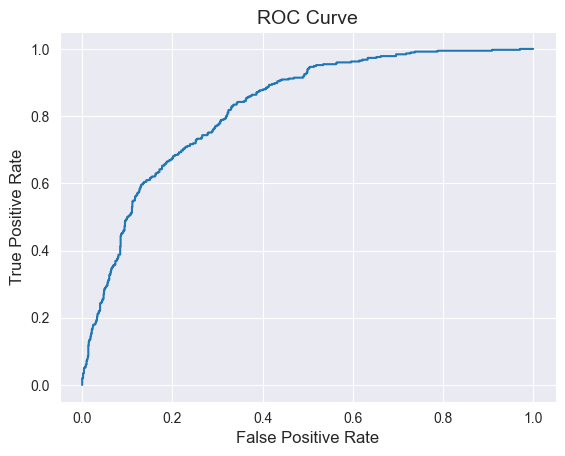

In [165]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

pipeline.fit(X_train, Y_train)
probs = pipeline.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(Y_test, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

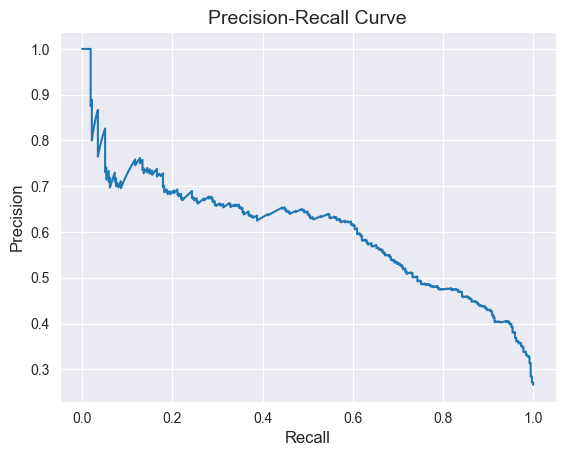

In [166]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(Y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()